In [1]:
#from B_1 import *
# from B_plot_funcs import *
from a_NN_Samplers_and_VI_algo import * 

In [2]:
def plot_heatmaps_t_stepsize_grid(title : str, loss_fn, t_values, step_sizes, n_grid=5, n_samples=20, drift = False, seed = None, sample_method = 'Brownian' ):

    grid = np.linspace(-2, 2, n_grid)
    step = grid[1] - grid[0]
    edges = np.linspace(grid.min()-step/2, grid.max()+step/2, len(grid)+1)
    EdgeX, EdgeY = np.meshgrid(edges, edges)
    cartesian_grid = np.array(np.meshgrid(grid, grid)).T.reshape(-1, 2)

    fig, axes = plt.subplots(len(t_values),len(step_sizes),figsize=(5 * len(step_sizes), 4 * len(t_values)))

    # Handle edge cases (1 row or 1 column)
    if len(t_values) == 1:
        axes = np.expand_dims(axes, axis=0)
    if len(step_sizes) == 1:
        axes = np.expand_dims(axes, axis=1)

    for i, t in enumerate(t_values):
        for j, step_size in enumerate(step_sizes):

            loss_means = []

            for k in range(cartesian_grid.shape[0]):
                startp = torch.tensor(cartesian_grid[k, :], dtype=torch.float32)

                if sample_method == 'Brownian':
                    metric = RiemannianMetric(loss_fn)
                    sampler = Brownian_sampler(metric, t, step_size, n_samples)
                else: #Euclidean: 
                    sampler = Euclidean_sampler(t, step_size, n_samples)

                BM_endpoints = sampler.sample_q_endpoints(
                    startp,
                    detach_from_mu=True, 
                    drift = drift,
                    random_state = seed)

                loss = loss_fn.Loss_batch(BM_endpoints)
                loss_mean = torch.mean(loss)
                log_loss = torch.log(loss_mean)

                loss_means.append(log_loss.item())

            Z = np.array(loss_means).reshape(n_grid, n_grid)
            ax = axes[i, j]
            pcm = ax.pcolormesh(EdgeX,EdgeY,Z,cmap="RdBu",alpha=0.5,shading="flat")

            ax.set_title(f"T={t}, $\eta$={step_size}")

            # Only label outer axes (cleaner)
            if i == len(t_values) - 1:
                ax.set_xlabel("$w_1$")
            if j == 0:
                ax.set_ylabel("$w_2$")

            fig.colorbar(pcm, ax=ax)
            print(f"T={t}, $\eta$={step_size}")
    fig.suptitle(f"{title} \n", fontsize=18)
    plt.tight_layout()
    plt.show()

In [3]:
loss_fn = Losses_BANAN()
metric = RiemannianMetric(loss_fn)

T=50, $\eta$=0.01
T=50, $\eta$=0.005
T=50, $\eta$=0.001
T=50, $\eta$=0.0005
T=100, $\eta$=0.01
T=100, $\eta$=0.005
T=100, $\eta$=0.001
T=100, $\eta$=0.0005
T=500, $\eta$=0.01
T=500, $\eta$=0.005
T=500, $\eta$=0.001
T=500, $\eta$=0.0005
T=1000, $\eta$=0.01
T=1000, $\eta$=0.005
T=1000, $\eta$=0.001
T=1000, $\eta$=0.0005


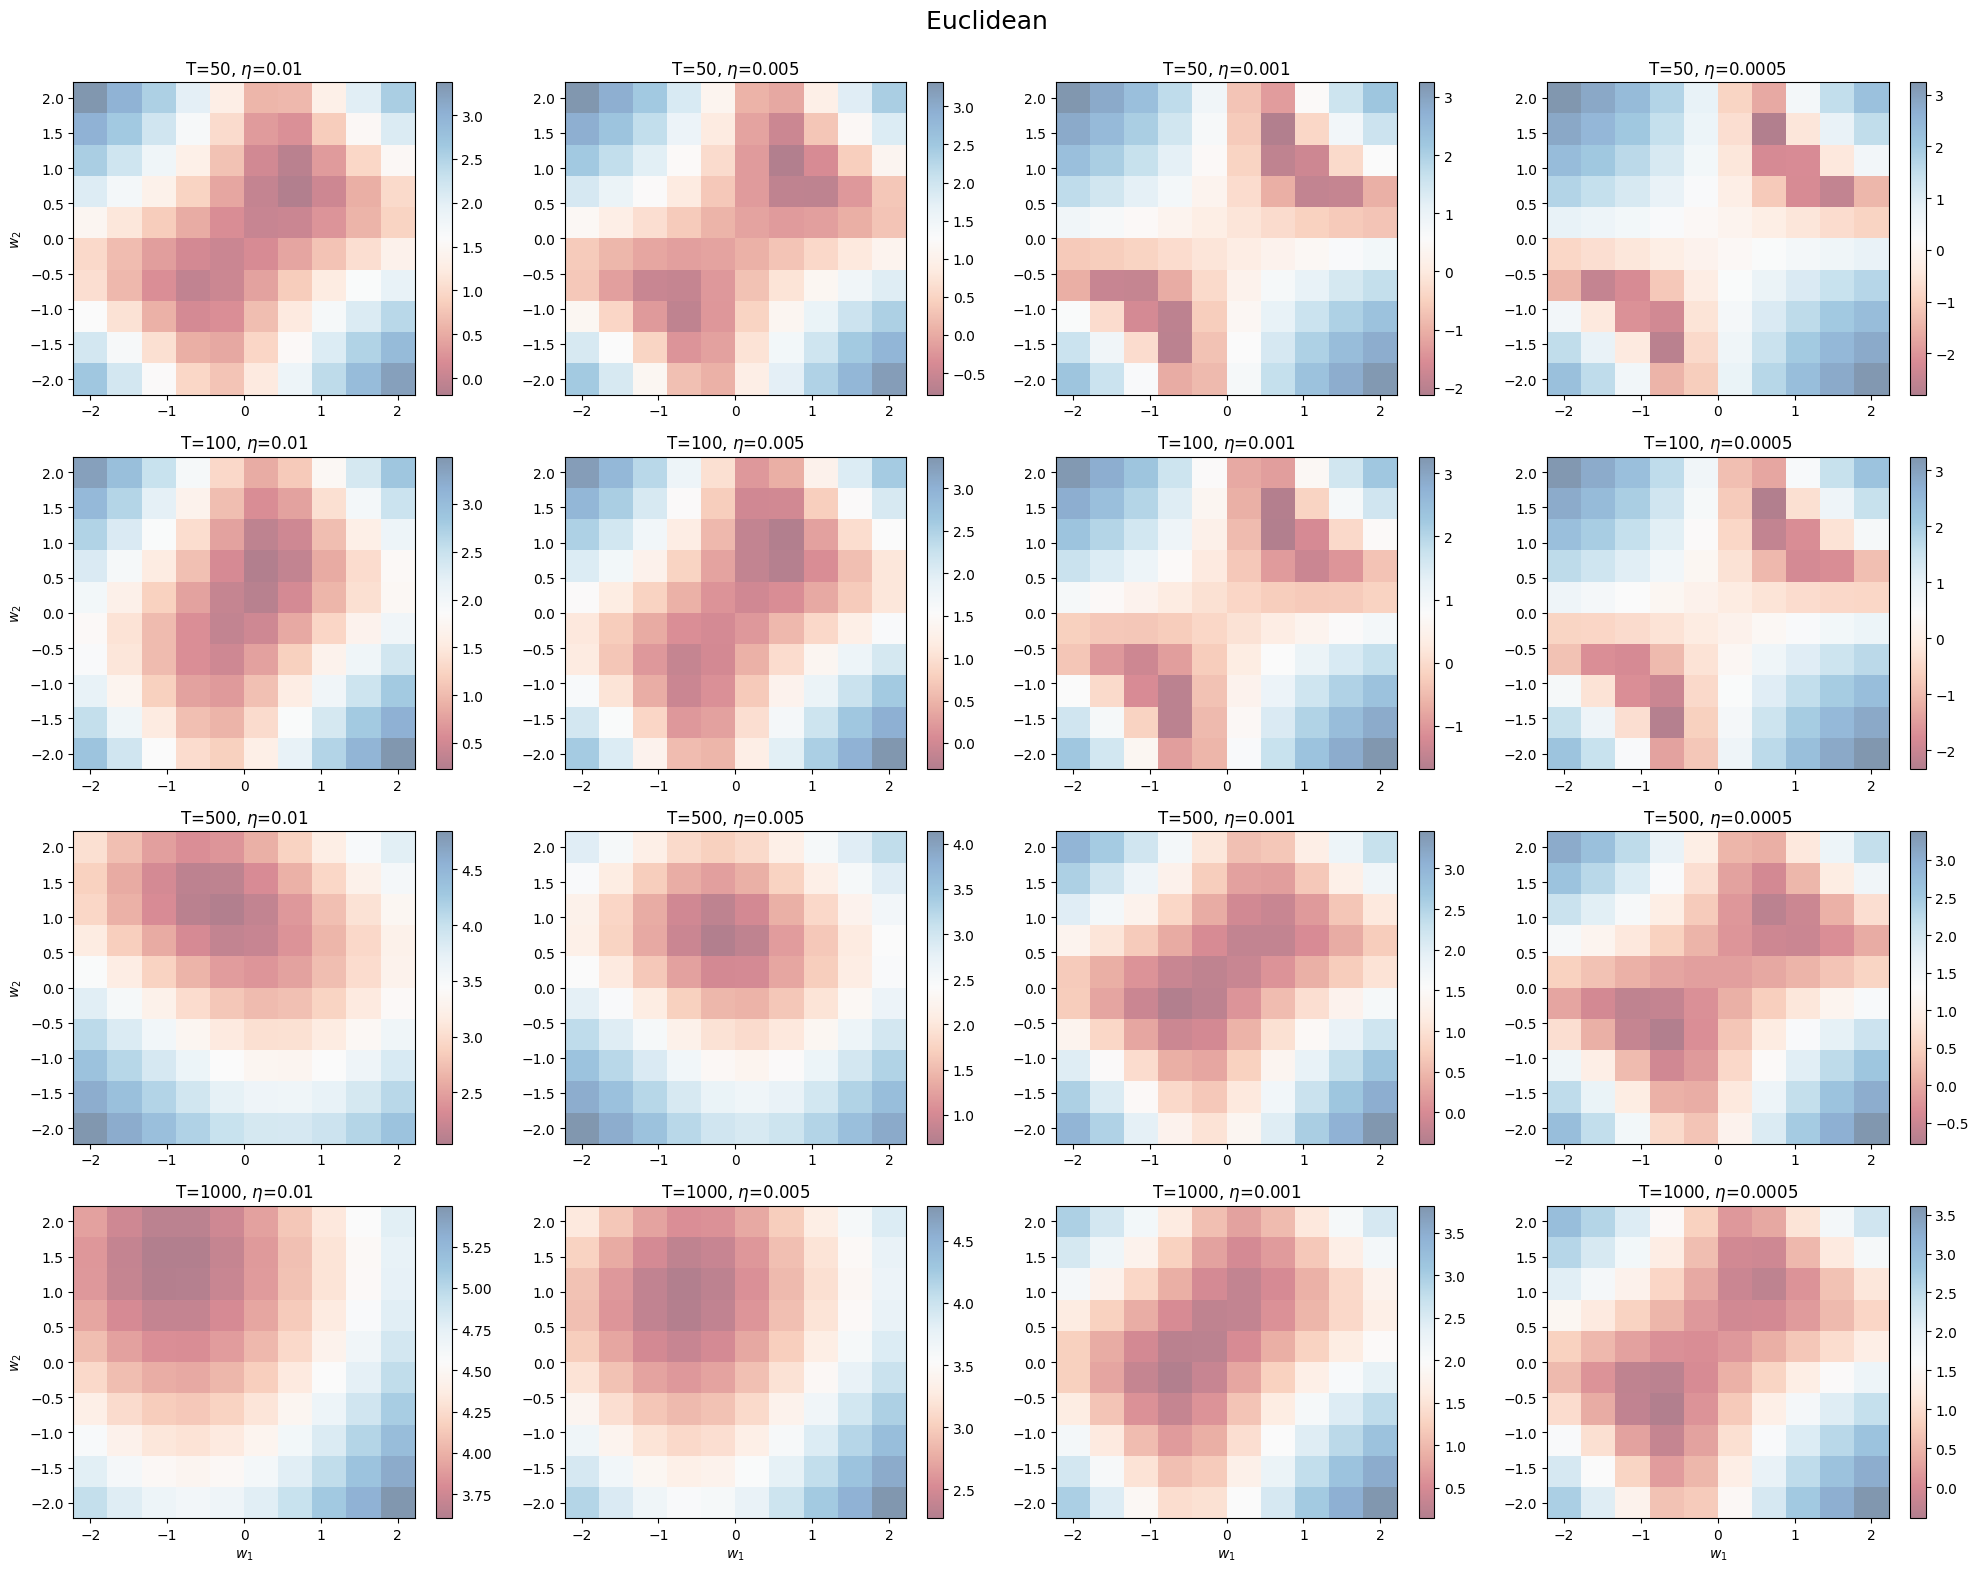

In [4]:
plot_heatmaps_t_stepsize_grid(
    'Euclidean ',
    loss_fn, 
    t_values=[50, 100, 500, 1000],
    step_sizes=[0.01,0.005, 0.001, 0.0005],
    n_grid=10,
    n_samples=20,
    seed = 13,
    sample_method = 'Euclidean')

In [5]:
plot_heatmaps_t_stepsize_grid(
    'Brownian, no drift',
    loss_fn, 
    t_values=[50, 100, 500, 1000],
    step_sizes=[0.01,0.005, 0.001, 0.0005],
    n_grid=10,
    n_samples=20,
    drift = False,
    seed = 13,
    sample_method = 'Brownian')

T=50, $\eta$=0.01
T=50, $\eta$=0.005
T=50, $\eta$=0.001
T=50, $\eta$=0.0005
T=100, $\eta$=0.01
T=100, $\eta$=0.005
T=100, $\eta$=0.001
T=100, $\eta$=0.0005


T=50, $\eta$=0.01
T=50, $\eta$=0.005
T=50, $\eta$=0.001
T=50, $\eta$=0.0005
T=100, $\eta$=0.01
T=100, $\eta$=0.005
T=100, $\eta$=0.001
T=100, $\eta$=0.0005
T=500, $\eta$=0.01
T=500, $\eta$=0.005
T=500, $\eta$=0.001
T=500, $\eta$=0.0005
T=1000, $\eta$=0.01
T=1000, $\eta$=0.005
T=1000, $\eta$=0.001
T=1000, $\eta$=0.0005


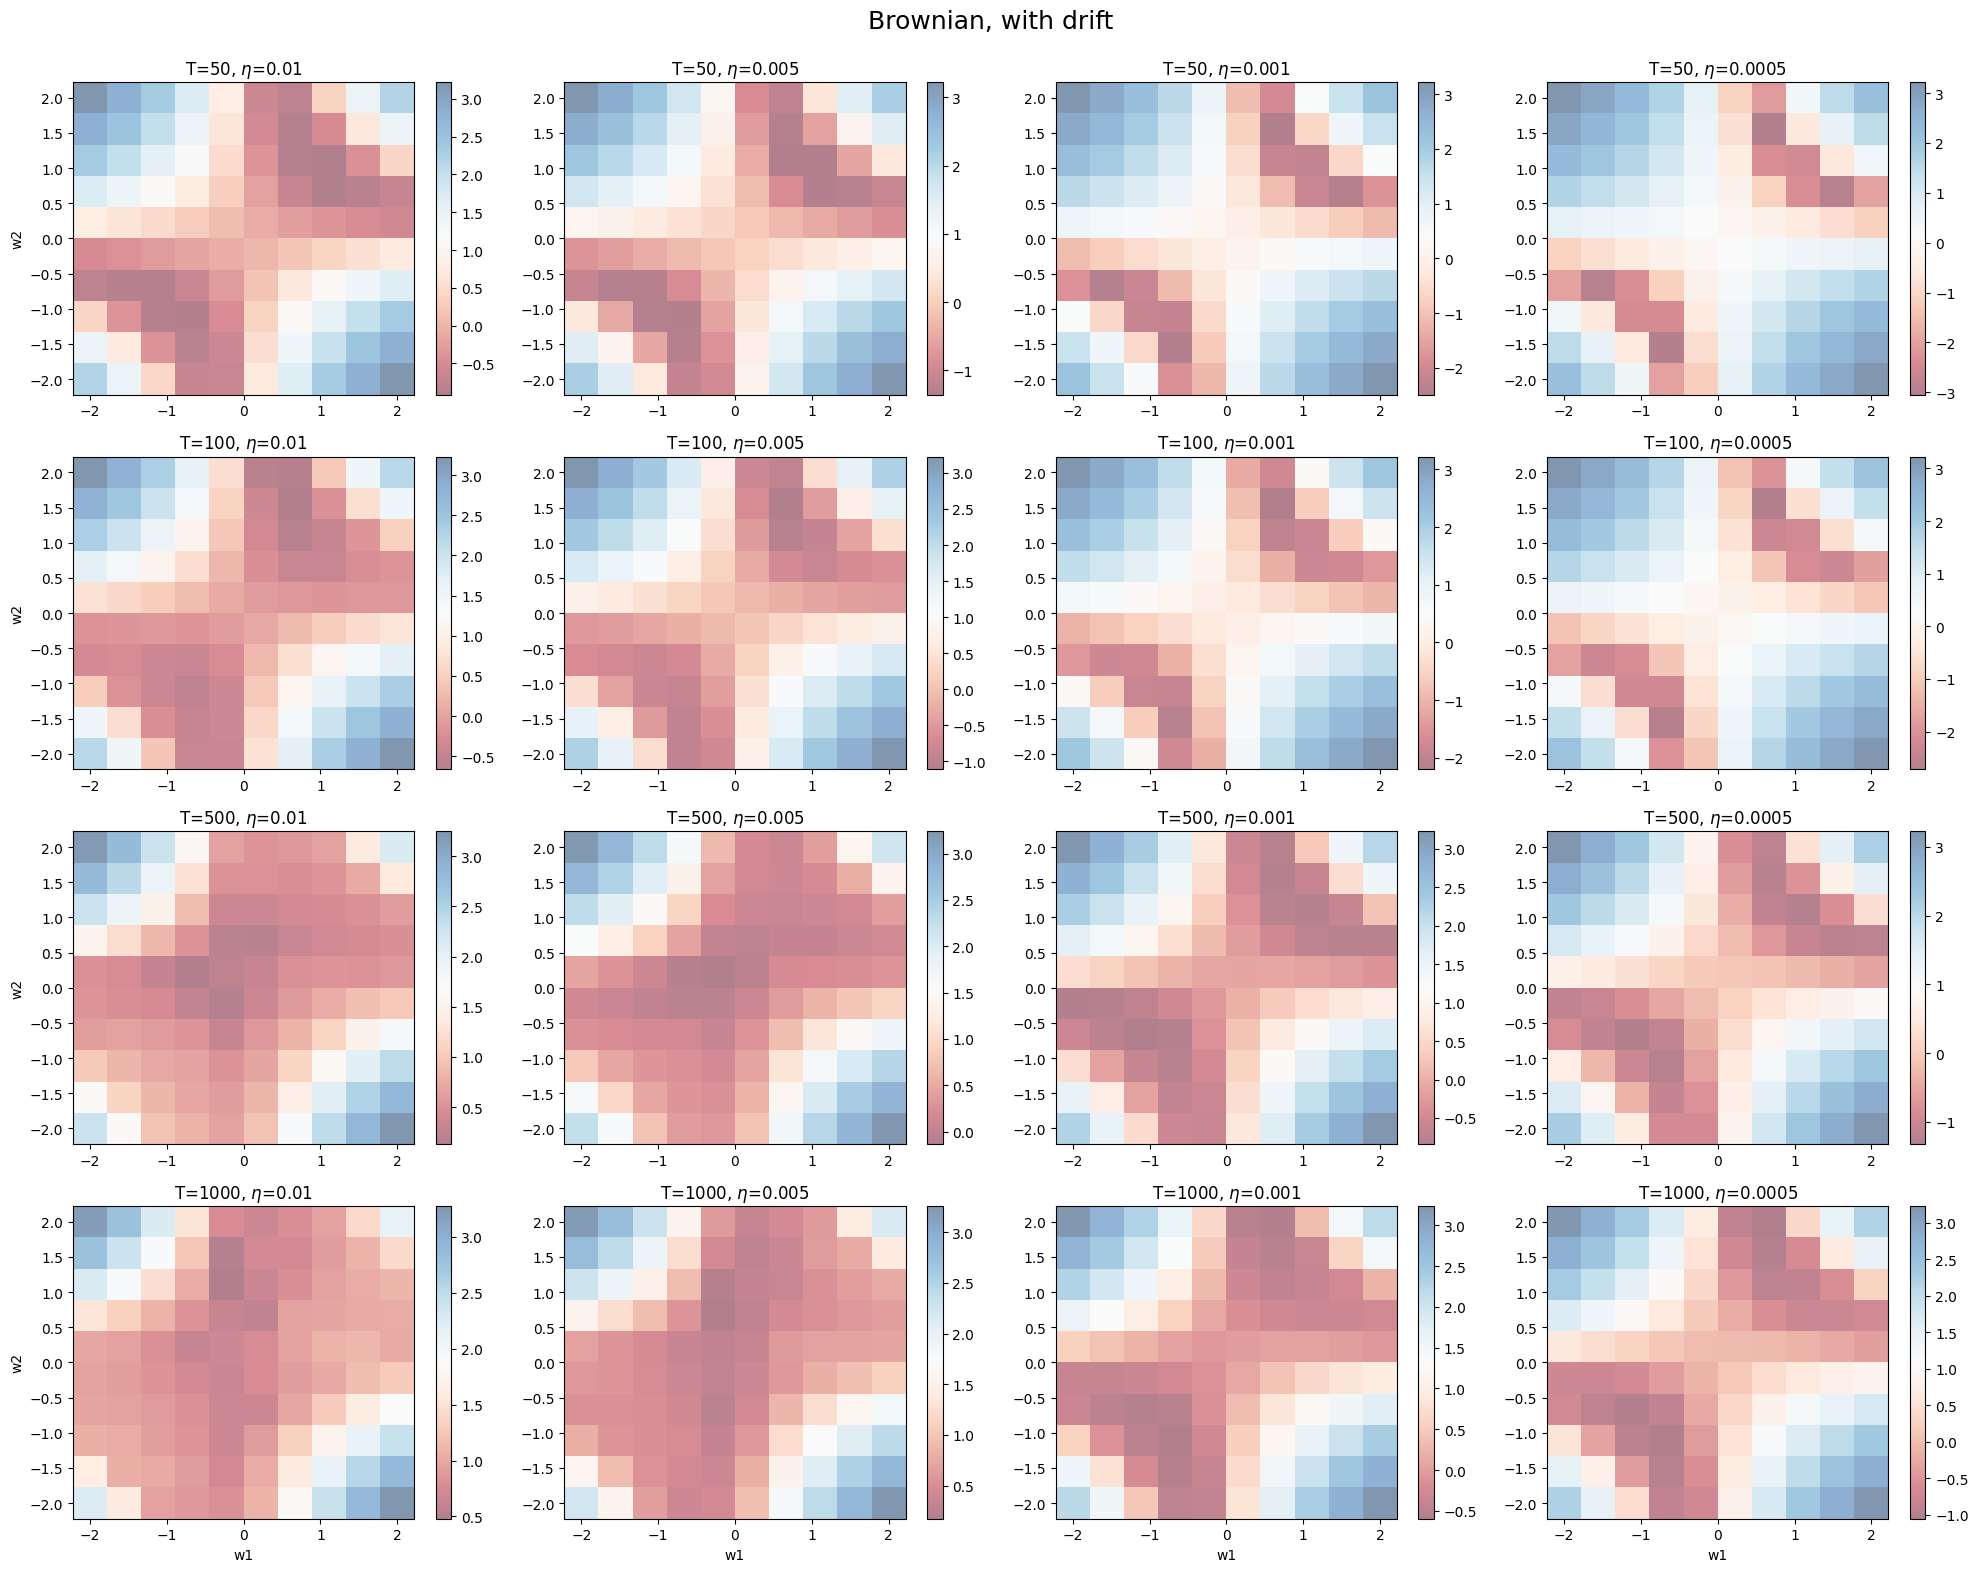

In [ ]:
plot_heatmaps_t_stepsize_grid(
    'Brownian, with drift',
    loss_fn, 
    t_values=[50, 100, 500, 1000],
    step_sizes=[0.01,0.005, 0.001, 0.0005],
    n_grid=10,
    n_samples=20,
    drift = True,
    seed = 13,
    sample_method = 'Brownian')

# With regularization

In [ ]:
def plot_heatmaps_t_stepsize_grid_reg(title : str, loss_fn, t_values, step_sizes, n_grid=5, n_samples=20, drift = False, seed = None, sample_method = 'Brownian', KL = 'VAN' , MMD_sigma =1):

    grid = np.linspace(-2, 2, n_grid)
    step = grid[1] - grid[0]
    edges = np.linspace(grid.min()-step/2, grid.max()+step/2, len(grid)+1)
    EdgeX, EdgeY = np.meshgrid(edges, edges)
    cartesian_grid = np.array(np.meshgrid(grid, grid)).T.reshape(-1, 2)
    
    fig, axes = plt.subplots(len(t_values),len(step_sizes),figsize=(5 * len(step_sizes), 4 * len(t_values)))

    # Handle edge cases (1 row or 1 column)
    if len(t_values) == 1:
        axes = np.expand_dims(axes, axis=0)
    if len(step_sizes) == 1:
        axes = np.expand_dims(axes, axis=1)

    for i, t in enumerate(t_values):
        for j, step_size in enumerate(step_sizes):

            loss_means = []

            for k in range(cartesian_grid.shape[0]):
                startp = torch.tensor(cartesian_grid[k, :], dtype=torch.float64)
                dim = startp.shape[-1]

                if sample_method == 'Brownian':
                    metric = RiemannianMetric(loss_fn)
                    sampler = Brownian_sampler(metric, t, step_size, n_samples)

                else: #Euclidean: 
                    sampler = Euclidean_sampler(t, step_size, n_samples)

                if KL == 'VAN':
                    ratio_net = RatioNet(dim).to(dtype=torch.float64)
                    X_q_det = sampler.sample_q_endpoints(startp, detach_from_mu=True, drift = drift, random_state = seed)
                    X_p_det = sampler.sample_prior(startp.dtype, startp.device, dim)
                    train_ratio_net(ratio_net, X_q_det, X_p_det)
                    BM_endpoints = sampler.sample_q_endpoints(startp, detach_from_mu=True, drift = drift, random_state = seed)
                    kl_term = ratio_net(BM_endpoints).mean()
                    loss = loss_fn.Loss_batch(BM_endpoints) + kl_term
                    loss_mean = torch.mean(loss)
                    log_loss = torch.log(loss_mean)
                    loss_means.append(log_loss.item())
                
                if KL == 'MMD':
                    BM_endpoints = sampler.sample_q_endpoints(startp, detach_from_mu=True, drift = drift, random_state = seed)
                    X_p = sampler.sample_prior(startp.dtype, startp.device, dim)
                    kl_term = MMD_loss_unbiased(BM_endpoints, X_p, param = MMD_sigma)
                    loss = loss_fn.Loss_batch(BM_endpoints) + kl_term
                    loss_mean = torch.mean(loss)
                    log_loss = torch.log(loss_mean)
                    loss_means.append(log_loss.item())

            Z = np.array(loss_means).reshape(n_grid, n_grid)
            ax = axes[i, j]
            pcm = ax.pcolormesh(EdgeX,EdgeY,Z,cmap="RdBu",alpha=0.5,shading="flat")

            ax.set_title(f"T={t}, $\eta$={step_size}")

            if i == len(t_values) - 1:
                ax.set_xlabel("$w_1$")
            if j == 0:
                ax.set_ylabel("$w_2$")

            fig.colorbar(pcm, ax=ax)
            print(f"T={t}, $\eta$={step_size}")
    fig.suptitle(f"{title} \n", fontsize=18)
    plt.tight_layout()
    plt.show()

T=50, $\eta$=0.01
T=50, $\eta$=0.005
T=50, $\eta$=0.001
T=50, $\eta$=0.0005
T=100, $\eta$=0.01
T=100, $\eta$=0.005
T=100, $\eta$=0.001
T=100, $\eta$=0.0005
T=500, $\eta$=0.01
T=500, $\eta$=0.005
T=500, $\eta$=0.001
T=500, $\eta$=0.0005
T=1000, $\eta$=0.01
T=1000, $\eta$=0.005
T=1000, $\eta$=0.001
T=1000, $\eta$=0.0005


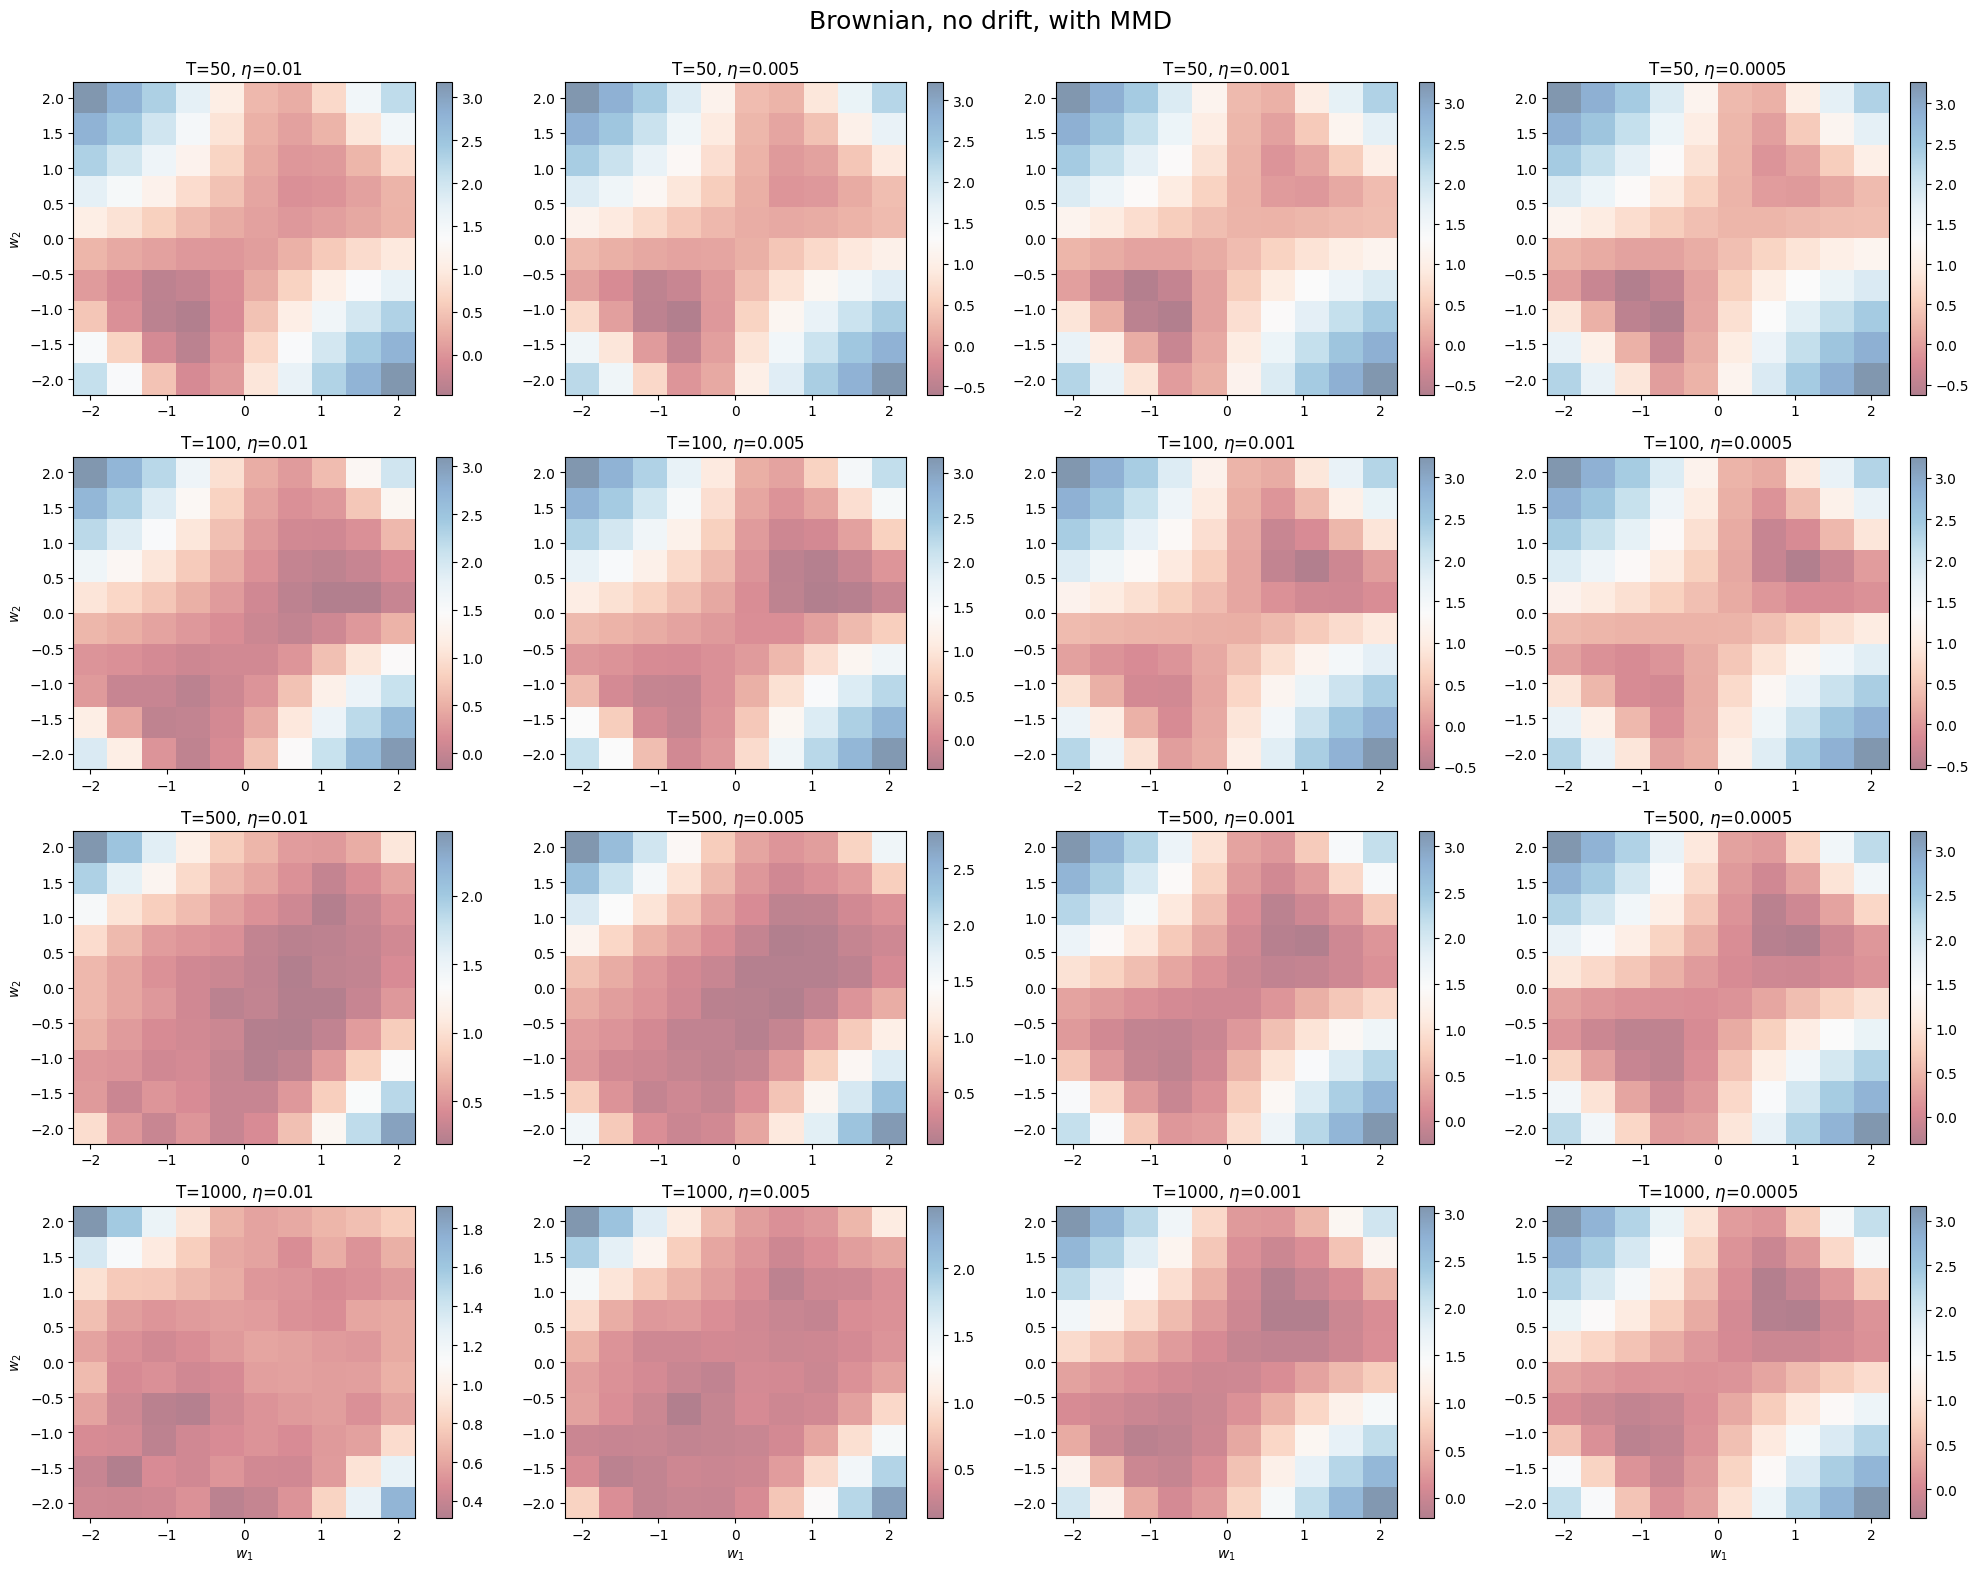

In [ ]:
plot_heatmaps_t_stepsize_grid_reg(
    'Brownian, no drift, with MMD',
    loss_fn, 
    t_values=[50, 100, 500, 1000],
    step_sizes=[0.01,0.005, 0.001, 0.0005],
    n_grid=10,
    n_samples=20,
    drift = False,
    seed = 13,
    sample_method = 'Brownian',
    KL = 'MMD')